# Mapa maturalnej matematyki — EDA

Eksploracja wyników egzaminu maturalnego z matematyki (Formuła 2023, aktualizacja
wrześniowa = sesja główna + poprawkowa) na tle języka polskiego i angielskiego.
Dane: CKE / [mapa.wyniki.edu.pl](https://mapa.wyniki.edu.pl), poziom powiatów i szkół,
lata 2023–2025.

**Cel biznesowy:** znaleźć wzorce pod dashboard-research rynku korepetycji
z matematyki (target: głównie licealiści — korepetycje; uczniowie 12–18 lat —
aplikacja do treningu) — gdzie popyt na wsparcie jest największy.

> **Zastrzeżenie metodologiczne:** w 2023 r. Formułę 2023 zdawali niemal wyłącznie
> absolwenci LO (technika kończyły Formułę 2015). Porównania LO/technikum
> i miasto/wieś liczymy więc wyłącznie na latach pełnych (2024–2025), a rok 2023
> na trendach oznaczamy adnotacją.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import data

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

counties = data.load_counties()
schools = data.load_schools()
W = data.weighted_mean  # średnia ważona liczbą zdających

partial_years = data.partial_coverage_years(schools)
full_years = sorted(set(schools["year"]) - partial_years)  # lata z technikami
years = sorted(counties["year"].unique())
latest = int(counties["year"].max())

print(f"powiaty: {counties.shape}, szkoły: {schools.shape}")
print(f"lata: {years} | pełne pokrycie (LO+technika): {full_years} | najnowszy: {latest}")

powiaty: (1135, 36), szkoły: (11836, 47)
lata: [2023, 2024, 2025] | pełne pokrycie (LO+technika): [2024, 2025] | najnowszy: 2025


## 1. Matematyka jako wąskie gardło matury

Zdawalność ogólna (świadectwo) jest z konstrukcji niższa od zdawalności każdego
pojedynczego przedmiotu, więc wąskie gardło identyfikujemy porównując przedmioty
między sobą (wszystkie na poziomie podstawowym, wagi = liczba zdających).

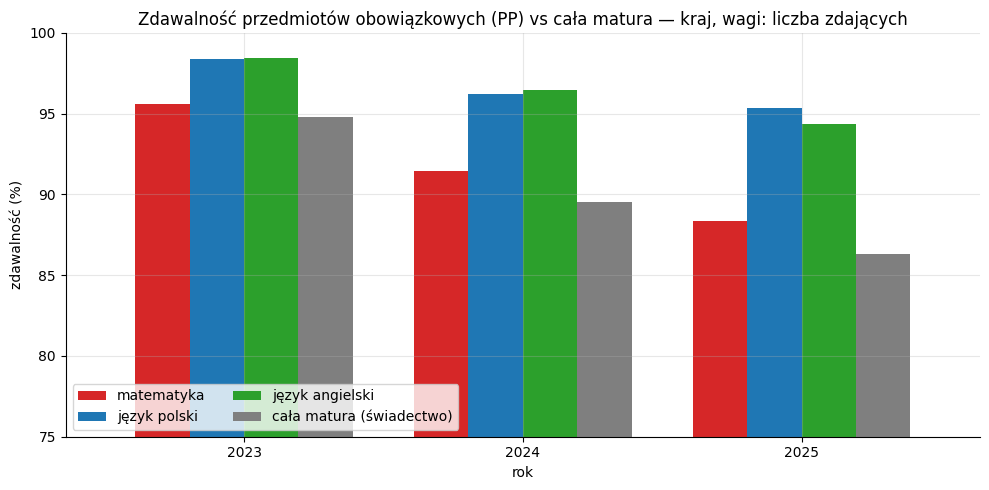

Matematyka najsłabsza z trójki przedmiotów w 93.7% powiato-lat
      matematyka  język polski  język angielski  cała matura (świadectwo)
rok                                                                      
2023        95.6          98.4             98.4                      94.8
2024        91.5          96.2             96.4                      89.5
2025        88.4          95.4             94.3                      86.3


In [2]:
rows = []
for y in years:
    g = counties[counties["year"] == y]
    rows.append({
        "rok": y,
        "matematyka": W(g, "math_pp_pass_rate", "math_pp_n"),
        "język polski": W(g, "pol_pp_pass_rate", "pol_pp_n"),
        "język angielski": W(g, "eng_pp_pass_rate", "eng_pp_n"),
        "cała matura (świadectwo)": W(g, "overall_pass_rate", "overall_taken"),
    })
national = pd.DataFrame(rows).set_index("rok")

ax = national.plot.bar(rot=0, width=0.78, color=["#d62728", "#1f77b4", "#2ca02c", "#7f7f7f"])
ax.set_ylim(75, 100)
ax.set_ylabel("zdawalność (%)")
ax.set_title("Zdawalność przedmiotów obowiązkowych (PP) vs cała matura — kraj, wagi: liczba zdających")
ax.legend(loc="lower left", ncol=2)
plt.tight_layout(); plt.show()

subj = counties[["math_pp_pass_rate", "pol_pp_pass_rate", "eng_pp_pass_rate"]]
math_worst = (subj.idxmin(axis=1) == "math_pp_pass_rate").mean()
print(f"Matematyka najsłabsza z trójki przedmiotów w {math_worst:.1%} powiato-lat")
print(national.round(1))

**Wniosek:** matematyka jest wąskim gardłem matury w całym kraju — w 2025 r.
zdawalność 88,4% wobec 95,4% (polski) i 94,3% (angielski); najsłabsza z trójki
w ~94% powiato-lat. **Biznesowo:** to matematyka generuje niemal cały rynek
„ratowania matury", a przewaga polskiego/angielskiego rośnie z każdym rokiem
dochodzenia techników do formuły.

## 2. Rozstrzał między powiatami

Czy problem jest wszędzie taki sam? Rozkład zdawalności matematyki PP po powiatach
(tylko powiaty z ≥100 zdających — mniejsze dają niestabilne odsetki).

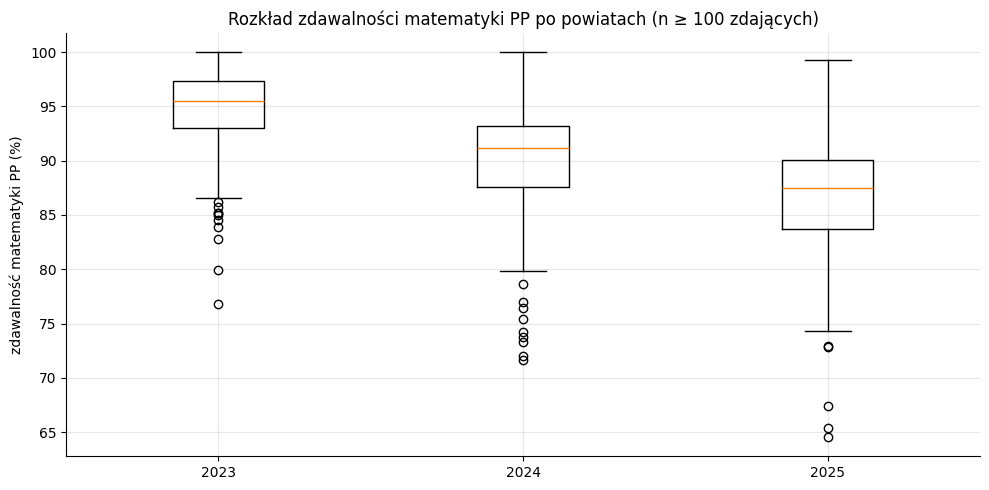

--- 2025: 10 najsłabszych powiatów ---
       voivodeship        county  math_pp_pass_rate  math_pp_n
          Opolskie    głubczycki               64.6        242
     Wielkopolskie międzychodzki               65.4        157
    Świętokrzyskie   kazimierski               67.4        138
         Lubelskie      lubelski               72.8        245
Zachodniopomorskie  choszczeński               72.9        188
       Mazowieckie  szydłowiecki               74.3        106
          Opolskie   namysłowski               75.5        221
      Dolnośląskie    polkowicki               75.6        199
    Świętokrzyskie    pińczowski               75.7        149
       Mazowieckie    ostrołęcki               76.1        111
--- 2025: 5 najlepszych ---
   voivodeship       county  math_pp_pass_rate  math_pp_n
     Pomorskie        Sopot               99.2        388
Świętokrzyskie włoszczowski               97.4        389
   Mazowieckie    sierpecki               97.2        399
   Mazow

In [3]:
big = counties[counties["math_pp_n"] >= 100]

fig, ax = plt.subplots()
series = [big.loc[big["year"] == y, "math_pp_pass_rate"].dropna() for y in years]
ax.boxplot(series, labels=[str(y) for y in years], showfliers=True)
ax.set_ylabel("zdawalność matematyki PP (%)")
ax.set_title("Rozkład zdawalności matematyki PP po powiatach (n ≥ 100 zdających)")
plt.tight_layout(); plt.show()

bl = big[big["year"] == latest]
lo10 = bl.nsmallest(10, "math_pp_pass_rate")[["voivodeship", "county", "math_pp_pass_rate", "math_pp_n"]]
hi5 = bl.nlargest(5, "math_pp_pass_rate")[["voivodeship", "county", "math_pp_pass_rate", "math_pp_n"]]
print(f"--- {latest}: 10 najsłabszych powiatów ---")
print(lo10.round(1).to_string(index=False))
print(f"--- {latest}: 5 najlepszych ---")
print(hi5.round(1).to_string(index=False))

piv = counties.pivot_table(index="teryt_county", columns="year", values="math_pp_pass_rate").dropna()
print(f"korelacja zdawalności powiatów {full_years[0]} vs {latest}: "
      f"{piv[full_years[0]].corr(piv[latest]):.2f} — słabe powiaty są słabe trwale, to nie szum")

**Wniosek:** rozstrzał jest ogromny — od ~65% (głubczycki, międzychodzki) do ~99%
(Sopot); między najsłabszym a najlepszym powiatem jest ~35 p.p., a korelacja
międzyroczna ~0,7 pokazuje, że to trwała cecha lokalna, nie losowość arkusza.
**Biznesowo:** lokalizacja ma znaczenie — w najsłabszych powiatach co trzeci
maturzysta oblewa matematykę.

## 3. Gdzie jest rynek: liczba oblewających, nie tylko odsetek

Niska zdawalność w małym powiecie to mały rynek. Szacujemy **liczbę osób, które
oblały matematykę PP**: `liczba zdających × (1 − zdawalność)`.

Szacowana liczba oblewających matematykę PP w 2025: 30,027 osób


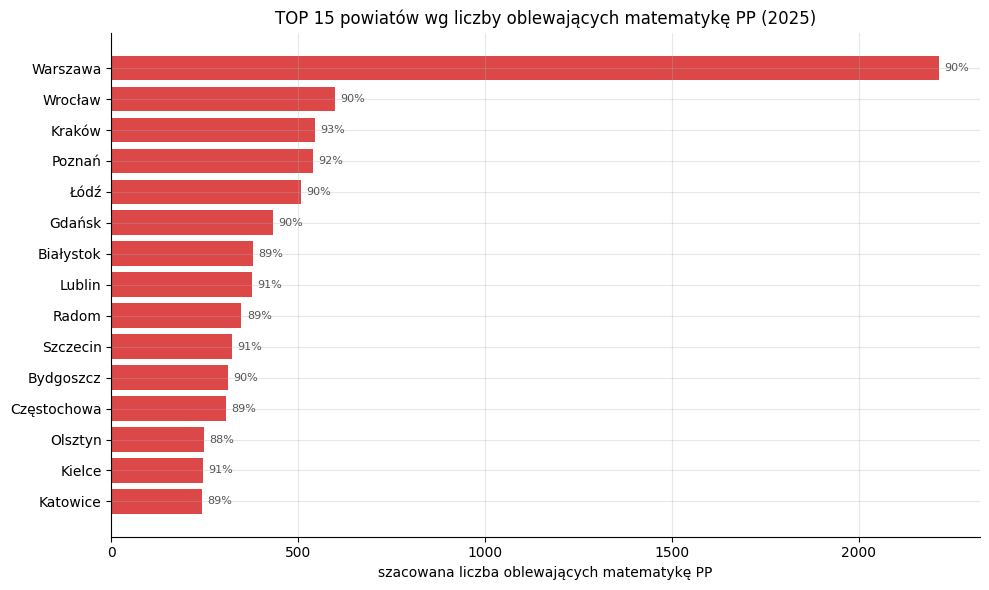

                     zdających  zdawalność ważona (%)  oblewający
voivodeship                                                      
Mazowieckie            45932.0                   89.4      4848.5
Śląskie                27516.0                   88.3      3216.0
Wielkopolskie          23964.0                   87.7      2937.1
Małopolskie            24721.0                   90.9      2255.3
Dolnośląskie           17033.0                   86.8      2244.9
Pomorskie              16042.0                   87.0      2091.1
Łódzkie                16170.0                   88.0      1939.0
Lubelskie              14426.0                   88.0      1735.7
Podkarpackie           14806.0                   88.7      1667.8
Kujawsko-Pomorskie     12454.0                   88.0      1489.3
Zachodniopomorskie      9534.0                   87.3      1213.2
Warmińsko-Mazurskie     8519.0                   86.2      1179.2
Podlaskie               7720.0                   88.2       913.3
Świętokrzy

In [4]:
cl = counties[counties["year"] == latest].copy()
cl["math_failers"] = cl["math_pp_n"] * (1 - cl["math_pp_pass_rate"] / 100)
print(f"Szacowana liczba oblewających matematykę PP w {latest}: {cl['math_failers'].sum():,.0f} osób")

top = cl.nlargest(15, "math_failers").iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top["county"], top["math_failers"], color="#d62728", alpha=0.85)
ax.set_xlabel("szacowana liczba oblewających matematykę PP")
ax.set_title(f"TOP 15 powiatów wg liczby oblewających matematykę PP ({latest})")
for _, r in top.iterrows():
    ax.text(r["math_failers"] + 15, r["county"], f'{r["math_pp_pass_rate"]:.0f}%',
            va="center", fontsize=8, color="#555")
plt.tight_layout(); plt.show()

by_voi = cl.groupby("voivodeship").apply(lambda g: pd.Series({
    "zdających": g["math_pp_n"].sum(),
    "zdawalność ważona (%)": W(g, "math_pp_pass_rate", "math_pp_n"),
    "oblewający": g["math_failers"].sum(),
}), include_groups=False).sort_values("oblewający", ascending=False)
print(by_voi.round(1).to_string())

**Wniosek:** wolumen rynku siedzi w dużych miastach — Warszawa (~2,2 tys.
oblewających rocznie), Wrocław, Kraków, Poznań, Łódź — mimo że ich zdawalność
jest *powyżej* średniej. **Biznesowo:** dwa segmenty rynku: (a) wielkomiejski
wolumen + zamożność (korepetycje „na wynik i na ambicje"), (b) powiaty o niskiej
zdawalności, gdzie potrzeba jest najostrzejsza, a podaż korepetytorów mała —
naturalny rynek dla aplikacji online.

## 4. Rozwarstwienie: LO vs technikum, miasto vs wieś

Tylko lata pełne (2024–2025). Histogram rozkładu zdawalności szkół
(szkoły z ≥10 zdających, żeby odsetki były stabilne).

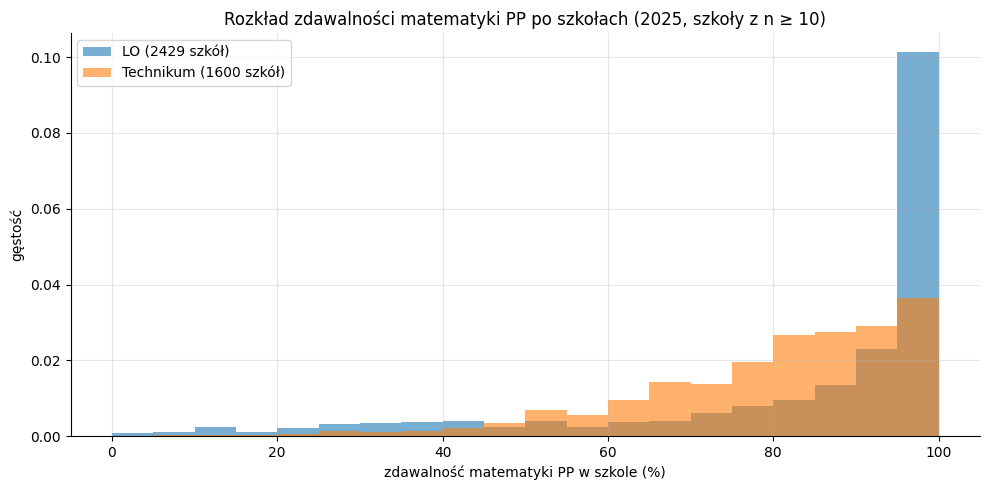

 rok       typ  zdawalność ważona (%)  średni wynik ważony (%)  zdających
2024        LO                   93.7                     68.2   150065.0
2024 Technikum                   88.7                     55.9    96539.0
2025        LO                   91.5                     66.5   163161.0
2025 Technikum                   83.5                     51.4    93949.0

-- miasto vs wieś z kontrolą typu szkoły (2025) --
  LO         miasto : zdawalność=91.6%  zdających=159,955
  LO         wieś   : zdawalność=85.7%  zdających=3,206
  Technikum  miasto : zdawalność=84.0%  zdających=89,116
  Technikum  wieś   : zdawalność=74.8%  zdających=4,833


In [5]:
sb = schools[(schools["year"] == latest) & (schools["math_pp_n"] >= 10)]

fig, ax = plt.subplots()
bins = range(0, 105, 5)
for kind, color in [("LO", "#1f77b4"), ("Technikum", "#ff7f0e")]:
    vals = sb.loc[sb["school_kind"] == kind, "math_pp_pass_rate"].dropna()
    ax.hist(vals, bins=bins, alpha=0.6, label=f"{kind} ({len(vals)} szkół)", color=color, density=True)
ax.set_xlabel("zdawalność matematyki PP w szkole (%)")
ax.set_ylabel("gęstość")
ax.set_title(f"Rozkład zdawalności matematyki PP po szkołach ({latest}, szkoły z n ≥ 10)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

rows = []
for y in full_years:
    for kind in ["LO", "Technikum"]:
        g = schools[(schools["year"] == y) & (schools["school_kind"] == kind)]
        rows.append({"rok": y, "typ": kind,
                     "zdawalność ważona (%)": W(g, "math_pp_pass_rate", "math_pp_n"),
                     "średni wynik ważony (%)": W(g, "math_pp_mean", "math_pp_n"),
                     "zdających": g["math_pp_n"].sum()})
print(pd.DataFrame(rows).round(1).to_string(index=False))

print("\n-- miasto vs wieś z kontrolą typu szkoły (%s) --" % latest)
for kind in ["LO", "Technikum"]:
    for rural, label in [(False, "miasto"), (True, "wieś")]:
        g = schools[(schools["year"] == latest) & (schools["is_rural"] == rural)
                    & (schools["school_kind"] == kind)]
        print(f"  {kind:10s} {label:7s}: zdawalność={W(g, 'math_pp_pass_rate', 'math_pp_n'):.1f}%  "
              f"zdających={g['math_pp_n'].sum():,.0f}")

**Wniosek:** dwa różne światy — w 2025 r. LO: zdawalność 91,5% (30% szkół ma
komplet 100%), technika: 83,5% i wyraźnie niższe wyniki (średni wynik 51% vs 67%).
Luka LO–technikum **rośnie** (5,0 p.p. w 2024 → 8,0 p.p. w 2025). Szkoły wiejskie
są słabsze nawet po kontroli typu szkoły (LO: −5,9 p.p., technika: −9,2 p.p.).
**Biznesowo:** uczeń technikum to niedoceniany segment — gorsze wyniki, mniej
korepetycji wokół, a matematyka tak samo obowiązkowa.

## 5. Ambicje: kto w ogóle podchodzi do rozszerzenia

Poziom rozszerzony nie ma progu zdawalności, więc porównujemy **uczestnictwo**:
`ambition_ratio = zdający PR / zdający PP` (0 = nikt nie podchodzi).

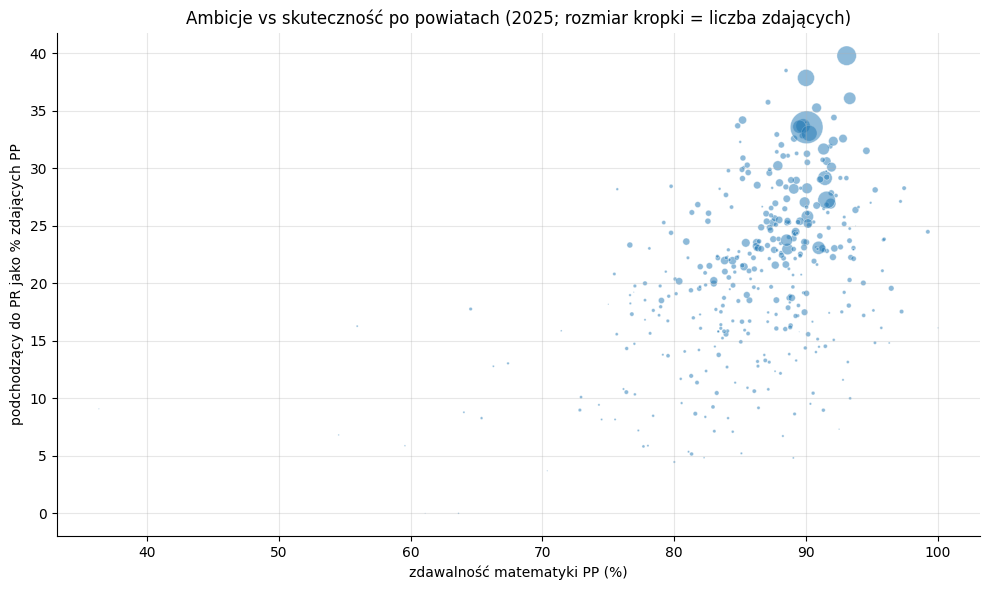

korelacja ambition_ratio vs zdawalność PP (powiaty, 2025): 0.46

powiaty z ZEROWYM uczestnictwem w PR: {2023: 5, 2024: 5, 2025: 2}
 year        voivodeship        county  math_pp_n
 2023          Podlaskie     łomżyński          8
 2023            Łódzkie   piotrkowski         23
 2023            Łódzkie skierniewicki         23
 2023 Zachodniopomorskie   koszaliński         12
 2023 Zachodniopomorskie    sławieński         38
 2024          Lubelskie      chełmski         66
 2024          Podlaskie     łomżyński         14
 2024          Podlaskie      suwalski         11
 2024      Wielkopolskie   leszczyński          7
 2024 Zachodniopomorskie   koszaliński         54
 2025          Lubelskie      chełmski         44
 2025          Podlaskie      suwalski         18

udział podchodzących do PR per województwo (ważony):
voivodeship
Zachodniopomorskie     19.2%
Kujawsko-Pomorskie     21.3%
Lubuskie               21.9%
Wielkopolskie          23.4%
Śląskie                23.6%
Warmińsk

In [6]:
cl = counties[counties["year"] == latest]

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(cl["math_pp_pass_rate"], cl["ambition_ratio"] * 100,
                s=cl["math_pp_n"] / 40, alpha=0.5, c="#1f77b4", edgecolor="white", linewidth=0.5)
ax.set_xlabel("zdawalność matematyki PP (%)")
ax.set_ylabel("podchodzący do PR jako % zdających PP")
ax.set_title(f"Ambicje vs skuteczność po powiatach ({latest}; rozmiar kropki = liczba zdających)")
plt.tight_layout(); plt.show()

corr = cl[["ambition_ratio", "math_pp_pass_rate"]].corr().iloc[0, 1]
print(f"korelacja ambition_ratio vs zdawalność PP (powiaty, {latest}): {corr:.2f}")

zero = counties[counties["ambition_ratio"] == 0]
print(f"\npowiaty z ZEROWYM uczestnictwem w PR: "
      f"{zero.groupby('year')['county'].count().to_dict()}")
print(zero[["year", "voivodeship", "county", "math_pp_n"]].to_string(index=False))

amb_voi = cl.groupby("voivodeship").apply(
    lambda g: W(g, "ambition_ratio", "math_pp_n"), include_groups=False
).sort_values()
print("\nudział podchodzących do PR per województwo (ważony):")
print((amb_voi * 100).round(1).astype(str).add("%").to_string())

**Wniosek:** ambicje idą w parze ze skutecznością (korelacja ~0,46) — tam, gdzie
zdawalność PP niska, do rozszerzenia podchodzi ledwie kilkanaście procent
(Zachodniopomorskie 19% vs Małopolskie 30%). Skrajność: powiaty chełmski
i suwalski z **zerowym** uczestnictwem w PR. **Biznesowo:** podwójne wykluczenie —
regiony słabe w PP nie mają też kandydatów na studia techniczne; rynek
przygotowania do PR koncentruje się w metropoliach i na południowym wschodzie.

## 6. Trend 2023–2025

Pełna populacja nie jest porównywalna między latami (2023 = tylko LO), więc trend
pokazujemy dwutorowo: cała populacja Formuły 2023 + **samo LO** (porównywalne
przez wszystkie trzy lata).

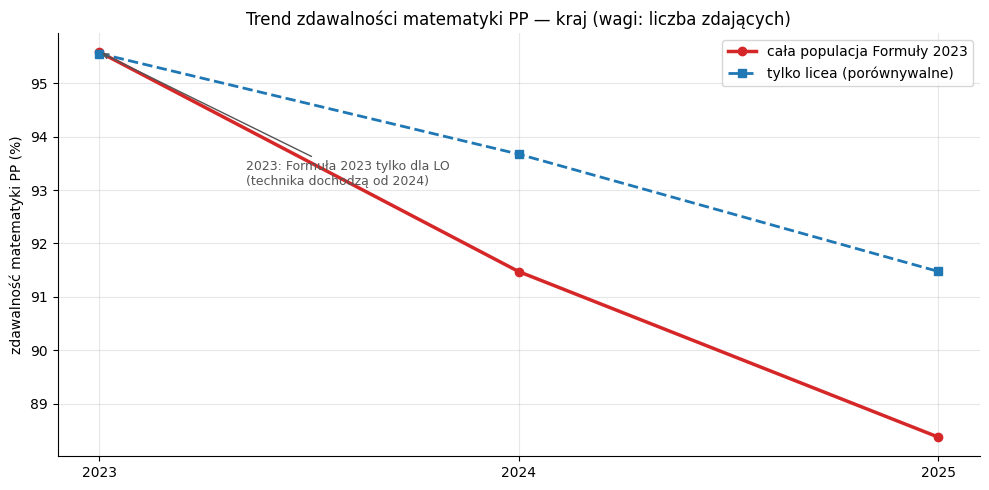

      cała populacja  tylko LO
2023            95.6      95.6
2024            91.5      93.7
2025            88.4      91.5

spadek w samych LO 2023→2025: 4.1 p.p.


In [7]:
lo = schools[schools["school_kind"] == "LO"]
trend = pd.DataFrame({
    "cała populacja": [W(counties[counties["year"] == y], "math_pp_pass_rate", "math_pp_n") for y in years],
    "tylko LO": [W(lo[lo["year"] == y], "math_pp_pass_rate", "math_pp_n") for y in years],
}, index=years)

fig, ax = plt.subplots()
ax.plot(trend.index, trend["cała populacja"], "o-", lw=2.5, color="#d62728", label="cała populacja Formuły 2023")
ax.plot(trend.index, trend["tylko LO"], "s--", lw=2, color="#1f77b4", label="tylko licea (porównywalne)")
first_partial = min(partial_years) if partial_years else None
if first_partial:
    ax.annotate("2023: Formuła 2023 tylko dla LO\n(technika dochodzą od 2024)",
                xy=(first_partial, trend.loc[first_partial, "cała populacja"]),
                xytext=(first_partial + 0.35, trend.loc[first_partial, "cała populacja"] - 2.5),
                arrowprops=dict(arrowstyle="->", color="#555"), fontsize=9, color="#555")
ax.set_xticks(years)
ax.set_ylabel("zdawalność matematyki PP (%)")
ax.set_title("Trend zdawalności matematyki PP — kraj (wagi: liczba zdających)")
ax.legend()
plt.tight_layout(); plt.show()

print(trend.round(1).to_string())
print(f"\nspadek w samych LO {years[0]}→{latest}: "
      f"{trend['tylko LO'].iloc[0] - trend['tylko LO'].iloc[-1]:.1f} p.p.")

**Wniosek:** zdawalność spada nawet w porównywalnej populacji LO: 95,6% → 93,7%
→ 91,5% (−4,1 p.p. w dwa lata) — to nie tylko efekt dojścia techników.
Prawdopodobny kontekst zewnętrzny to stopniowe odchodzenie od pandemicznych
ułatwień egzaminacyjnych — dane CKE pokazują sam spadek, nie jego przyczynę.
**Biznesowo:** rynek nie maleje — z roku na rok przybywa maturzystów z problemem
z matematyką (30 tys. oblewających w 2025 przy 258 tys. zdających).

---

## Podsumowanie — wzorce pod aplikację

| # | Wzorzec | Liczby | Sekcja aplikacji |
|---|---------|--------|------------------|
| 1 | Matematyka = wąskie gardło matury | 88,4% vs 95,4% (polski) i 94,3% (angielski); najsłabsza w 94% powiato-lat | Start / KPI + słupki |
| 2 | Trwały rozstrzał powiatowy 35 p.p. | 64,6% (głubczycki) – 99,2% (Sopot); korelacja międzyroczna 0,7 | Mapa choropleth |
| 3 | Rynek = wolumen: metropolie dominują liczbą oblewających | Warszawa ~2,2 tys./rok; kraj ~30 tys. | Mapa + scatter |
| 4 | LO vs technikum: luka rośnie (5,0 → 8,0 p.p.), wieś słabsza nawet w ramach typu | technika 83,5%, LO 91,5% (2025) | Rozwarstwienie (histogram + box) |
| 5 | Ambicje skorelowane ze skutecznością; zero-PR powiaty na ścianie wschodniej | korelacja 0,46; chełmski/suwalski = 0% PR | Ambicje i trendy |